In [16]:
%pip install datasets

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from textwrap import wrap
from datasets import load_dataset, Dataset, DatasetDict
from torchvision import transforms

mydata = load_dataset('valhalla/emoji-dataset')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [27]:
# include_keywords = ['face','christmas','superhero','supervillian','mage','vampire','monkey','elf','juggling',
#             'boy','girl','adult','person','man','woman','male','female','worker','scientist','technologist',
#             'singer','artist','pilot','astronaut','firefighter','police','sleuth','construction']
include_keywords = ['face']

exclude_keywords = ["clock", "gesture", "moon", "palm", "massage", "wind", "pout",
                    "mouse", "lion", "dragon", "giraffe", "monkey", "dog", "cow", "horse",
                    "zebra", "wolf", "fox", "pig", "rabbit", "panda", "hamster",
                    "bear", "unicorn", "frog"]

def keep_row(example):
    title = (example.get("text") or "").lower()

    inc = any(k.lower() in title for k in include_keywords) if include_keywords else True
    exc = any(k.lower() in title for k in exclude_keywords) if exclude_keywords else False

    return inc and not exc

def preprocess(example):
    im = example["image"].convert("RGB").resize((64, 64), Image.LANCZOS)
    example["image"] = im
    return example

plt.rcParams["figure.figsize"] = [1.5, 1.50]

mydata = load_dataset('valhalla/emoji-dataset')
mydata = mydata.filter(keep_row)
mydata = mydata.map(preprocess)

Filter:   0%|          | 0/2749 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

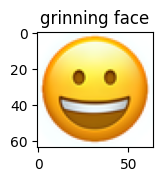

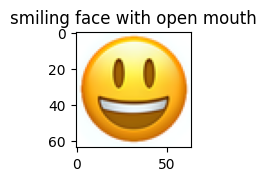

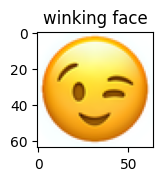

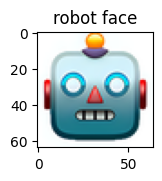

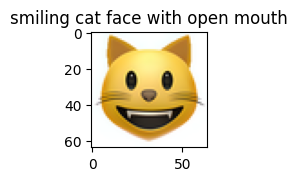

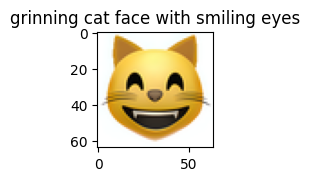

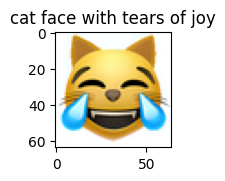

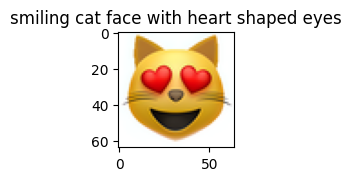

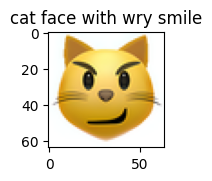

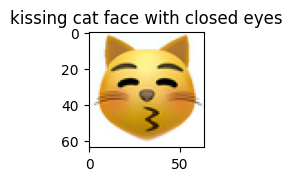

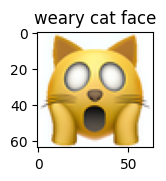

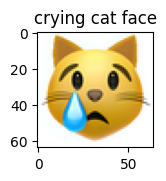

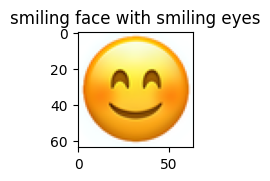

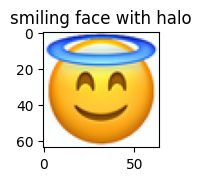

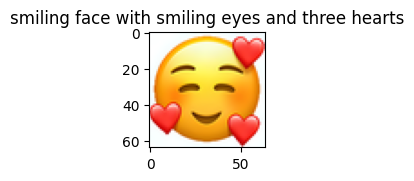

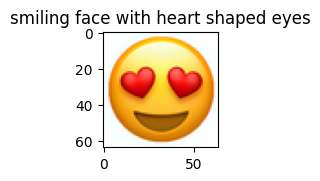

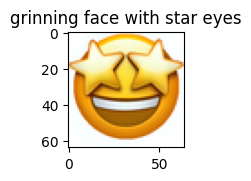

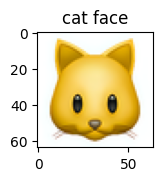

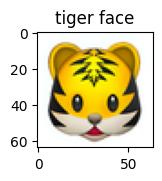

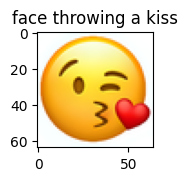

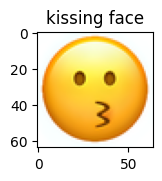

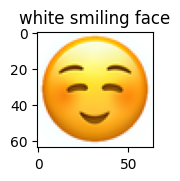

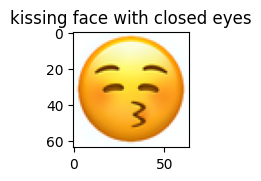

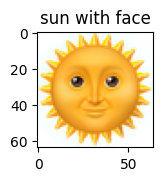

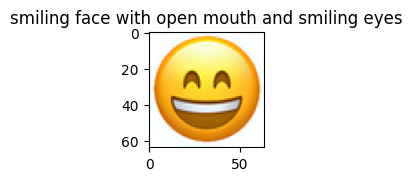

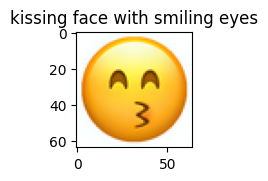

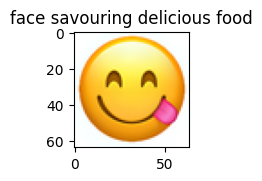

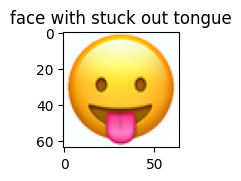

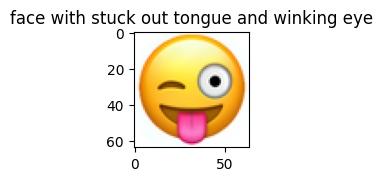

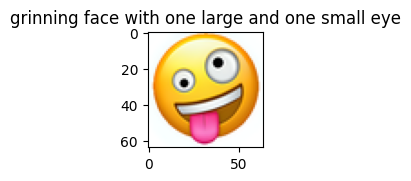

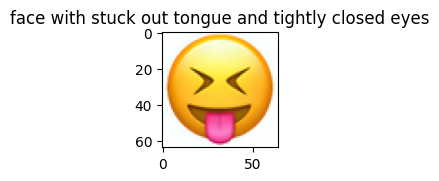

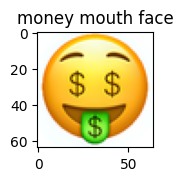

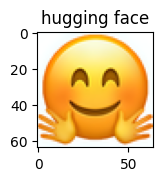

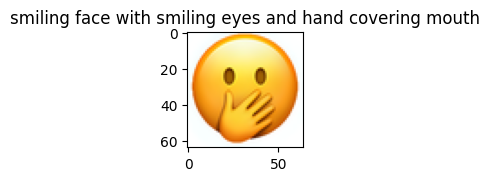

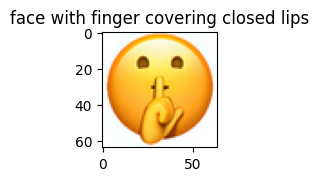

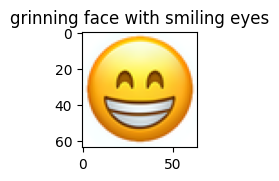

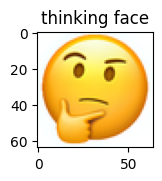

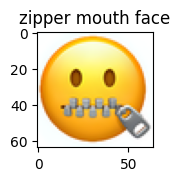

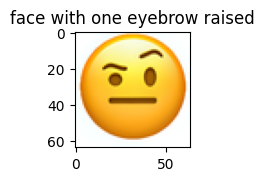

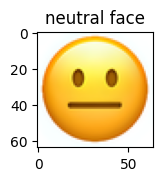

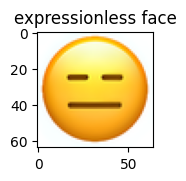

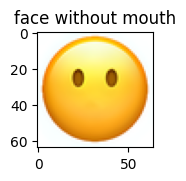

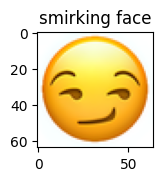

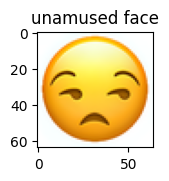

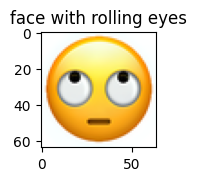

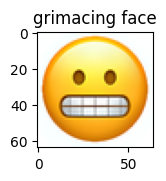

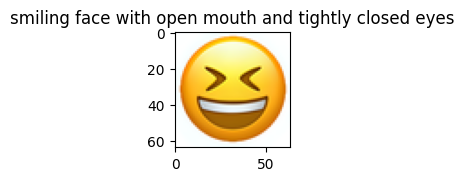

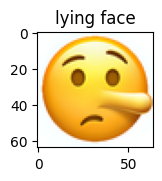

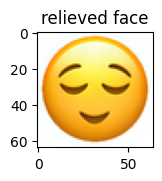

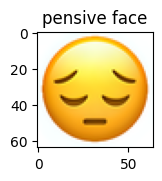

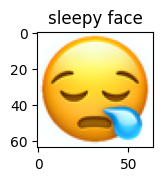

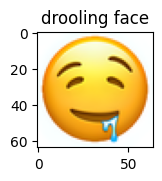

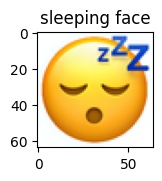

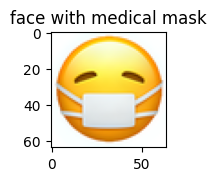

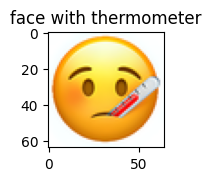

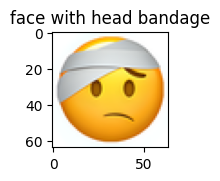

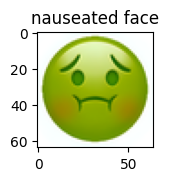

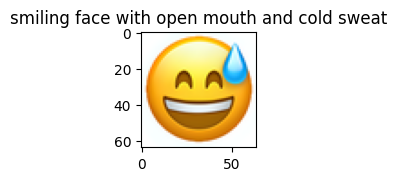

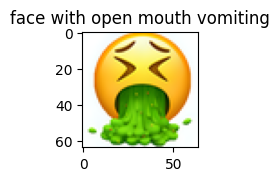

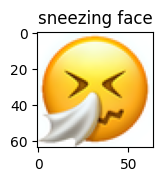

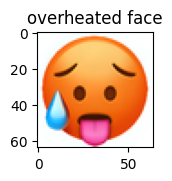

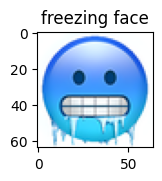

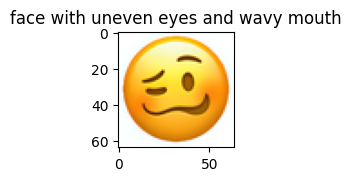

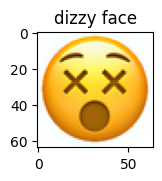

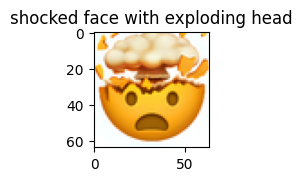

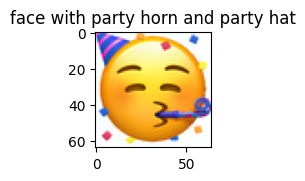

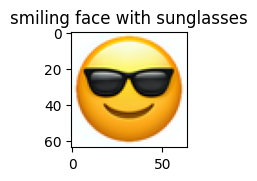

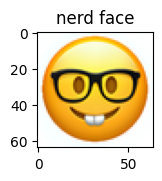

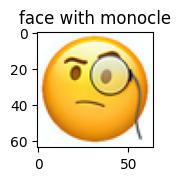

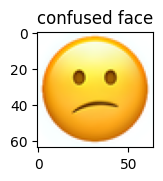

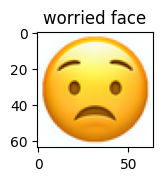

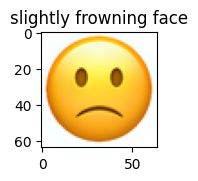

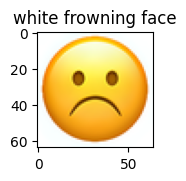

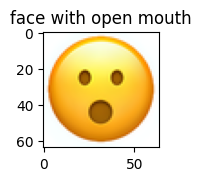

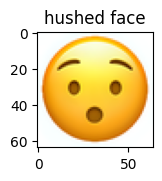

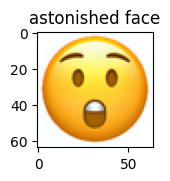

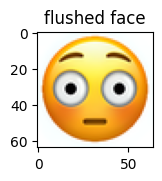

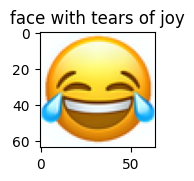

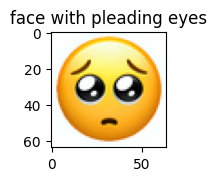

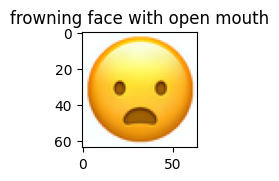

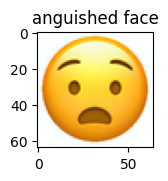

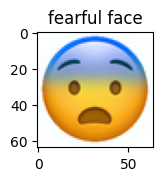

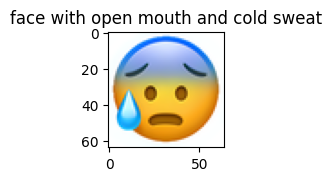

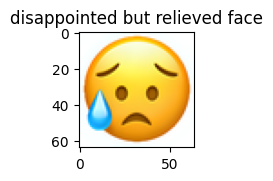

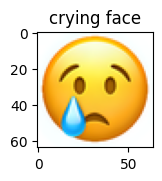

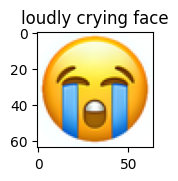

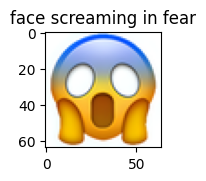

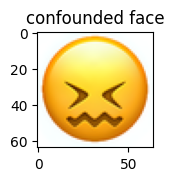

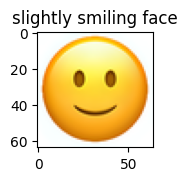

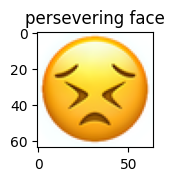

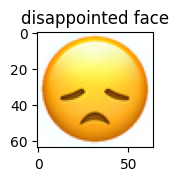

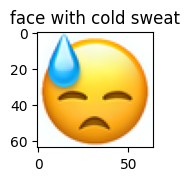

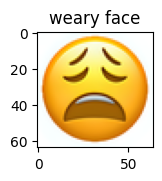

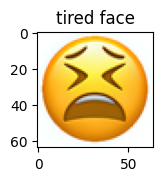

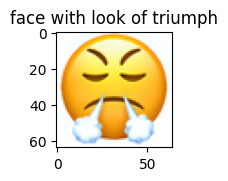

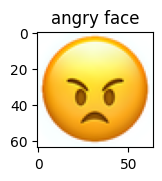

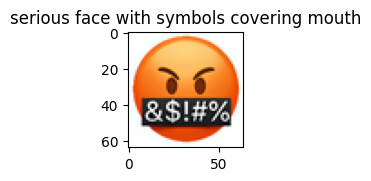

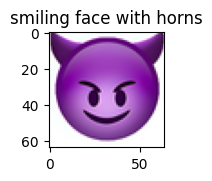

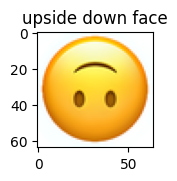

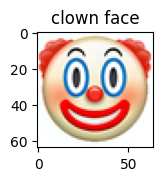

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 100
    })
})


In [35]:
def show_images(dset: Dataset, first_n: int = -1):
  for idx, example in enumerate(dset):
      if first_n > 0 and idx >= first_n:
          break
      plt.imshow(example['image'])
      plt.title(example['text'])
      plt.show()


show_images(mydata['train'])
print(mydata)

# Preprocessing / Data Augmentation

For augmentation, I perform the following operations:
- rotations
- shifts
- saturation adjustments
- brightness adjustments

For now, sticking to the assignment guidelines, I will just pre-process my data once, rather than re-augmenting my input data per epoch, though I think that'd be something to try if this doesn't work as well as I'd like.

In [40]:
from PIL import Image, ImageChops, ImageEnhance
import random

def augment_image(
    image: Image.Image,
    rotate_range=(-30, 30),        # degrees
    shift_range=(-10, 10),         # pixels
    hue_range=(-0.05, 0.05),       # subtle hue shift via R/G/B channel tweak
    saturation_range=(0.7, 1.3),   # multiplier
    brightness_range=(0.7, 1.3),   # multiplier (lightness proxy)
) -> Image.Image:
    # fill the borders with white
    fcolor = (255, 255, 255)

    # Rotate
    angle = random.uniform(*rotate_range)
    image = image.rotate(angle, resample=Image.BILINEAR, expand=False, fillcolor=fcolor)

    # Shift (translate via affine)
    dx = random.uniform(*shift_range)
    dy = random.uniform(*shift_range)
    image = image.transform(
        image.size,
        Image.AFFINE,
        (1, 0, -dx, 0, 1, -dy),
        resample=Image.BILINEAR,
        fillcolor=fcolor
    )

    # Saturation
    sat_factor = random.uniform(*saturation_range)
    image = ImageEnhance.Color(image).enhance(sat_factor)

    # Brightness (lightness proxy)
    bright_factor = random.uniform(*brightness_range)
    image = ImageEnhance.Brightness(image).enhance(bright_factor)

    return image


def augment_batch(batch):
    batch["image"] = [augment_image(img.convert("RGB")) for img in batch["image"]]
    return batch


augmented = mydata.map(augment_batch, batched=True, batch_size=32)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 100
    })
})


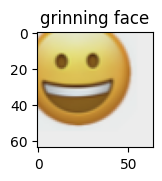

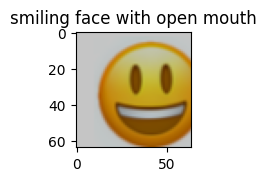

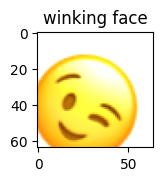

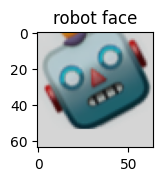

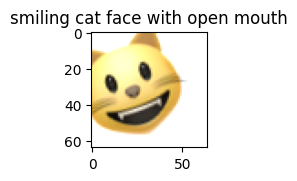

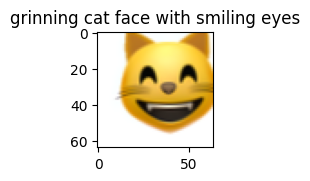

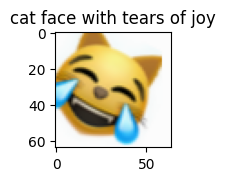

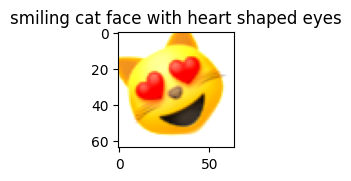

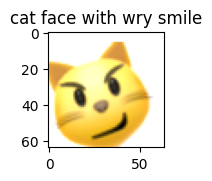

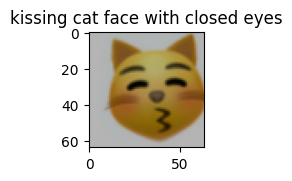

In [41]:
print(augmented)
show_images(augmented['train'], 10)

In [49]:
# change images over to tensors

def transform_images(batch):
    # Convert PIL Image to PyTorch Tensor and normalize to [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    batch["image"] = [transform(img.convert("RGB")) for img in batch["image"]]
    return batch

mydata_processed = mydata.map(transform_images, batched=True)
mydata_processed.set_format(type="torch", columns=["image"])



Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [51]:
train_val_test_dataset = mydata_processed['train'].train_test_split(test_size=0.4, seed=42)
val_test_dataset = train_val_test_dataset['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = train_val_test_dataset['train']
val_dataset = val_test_dataset['train']
test_dataset = val_test_dataset['test']

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 60
Validation set size: 20
Test set size: 20


# Model Definition + Training
In this I am roughly inspired [Radford et al](http://arxiv.org/abs/1511.06434)'s DCGAN generator architecture (Figure 1 in the paper linked).



In [52]:
from torch import nn

class Decoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.z_dim = z_dim

        # using a slightly less beefy version of DCGAN generator from Radford
        self.model = nn.Sequential(
            nn.BatchNorm1d(z_dim),
            # 1xz -> 256x4x4
            nn.Linear(z_dim, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),
            # conv 2
            nn.ConvTranspose2d(256, 128, (8, 8), 2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            # conv 2
            nn.ConvTranspose2d(128, 64, (16, 16), 2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            # conv 3 - back to the image
            nn.ConvTranspose2d(64, 3, (5, 5), 2),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Encoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.z_dim = z_dim
        # vaguely the same as the above in reverse
        self.model = nn.Sequential(
            nn.BatchNorm2d(64),
            # conv 1
            nn.Conv2d(3, 64, (5, 5), 2),
            nn.LeakyReLU(),
            # conv 2
            nn.Conv2d(64, 128, (16, 16), 2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            # conv 3
            nn.Conv2d(128, 256, (8, 8), 2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            # flatten
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, z_dim),
            nn.LeakyReLU()
        )

    def forward(self, x):
        return self.model(x)

class EmojiAE(nn.Module):
    """autoencoder for emojis"""
    def __init__(self, z_dim: int):
        """
        z_dim: latent space dimension
        """
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Training

In [50]:
learning_rate = 0.001
batch_size = 32
num_epochs = 50
z_dim = 16


**Reasoning**:
Now that the hyperparameters are defined, the next step is to prepare the data for training. This involves transforming the PIL images in the dataset into PyTorch tensors and creating DataLoader objects for the train, validation, and test sets to facilitate batch processing during training.



In [53]:
from torch.utils.data import DataLoader

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created for training, validation, and testing.")
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(val_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")

DataLoaders created for training, validation, and testing.
Number of training batches: 2
Number of validation batches: 1
Number of test batches: 1


**Reasoning**:
With the data prepared, the next step is to initialize the `EmojiAE` model, define the appropriate loss function for reconstruction (Mean Squared Error or Binary Cross-Entropy for normalized images), and select an optimizer to update the model weights during training.



In [54]:
import torch
from torch import nn

model = EmojiAE(z_dim=z_dim)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)